# Netflix Content Analysis

This project explores Netflix's catalog of movies and TV shows using exploratory data analysis. The dataset includes details such as content type, country, rating, genre, release year, and duration.

The analysis examines the composition of Netflix's catalog, common content categories, geographic distribution, and changes in the catalog over time. The goal is to identify meaningful patterns and summarize them using data-driven insights and visualizations.

## 1. Import Libraries
These libraries are used for data handling and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Load and Inspect the Dataset
The notebook is inside the `notebooks` folder, so `../data/` points to the data file.

In [3]:
df = pd.read_csv('../data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
print('Dataset shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types and non-null values:')
df.info()

df.describe(include='all')

Dataset shape: (8807, 12)

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data types and non-null values:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## 3. Data Quality Check
Before analysis, check missing values, duplicate rows, data types, and useful categorical values.

In [5]:
missing_values = df.isna().sum().reset_index()
missing_values.columns = ['Column', 'Missing Values']
missing_values['Missing Percentage'] = (missing_values['Missing Values'] / len(df) * 100).round(2)
missing_values.sort_values('Missing Values', ascending=False)

,Column,Missing Values,Missing Percentage
3,director,2634,29.91
5,country,831,9.44
4,cast,825,9.37
6,date_added,10,0.11
8,rating,4,0.05
9,duration,3,0.03
0,show_id,0,0.00
1,type,0,0.00
2,title,0,0.00
7,release_year,0,0.00


In [6]:
print('Duplicate rows:', df.duplicated().sum())
print('\nData types:')
print(df.dtypes)
print('\nUnique content types:', df['type'].unique())
print('Unique ratings:', df['rating'].dropna().unique())
print('Number of unique release years:', df['release_year'].nunique())

Duplicate rows: 0

Data types:
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

Unique content types: <StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str
Unique ratings: <StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR', 'TV-Y7-FV',       'UR']
Length: 17, dtype: str
Number of unique release years: 74


## 4. Data Cleaning
There are no duplicate rows in this dataset, but the code removes them so the notebook remains reusable. Whitespace is removed from text fields and `date_added` is converted to a date.

Missing directors and cast members can occur when title credits are unavailable. Missing countries and dates can occur when catalog metadata was not supplied. Those values are kept missing in the main dataset rather than being replaced with a label; only the relevant subset drops missing values when a chart needs that field.

In [7]:
df = df.drop_duplicates()

text_columns = df.select_dtypes(include='str').columns
for column in text_columns:
    df[column] = df[column].str.strip()

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

print('Shape after cleaning:', df.shape)
print('Duplicate rows after cleaning:', df.duplicated().sum())

Shape after cleaning: (8807, 12)
Duplicate rows after cleaning: 0


## 5. Exploratory Data Analysis
The following calculations answer the main questions about the Netflix catalog.

### Number and percentage of Movies and TV Shows

In [ ]:

content_type_counts = df['type'].value_counts()
content_type_percentages = (df['type'].value_counts(normalize=True) * 100).round(1)

print('Number of titles by type:')
print(content_type_counts)
print('\nPercentage of catalog by type:')
print(content_type_percentages)

Number of titles by type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Percentage of catalog by type:
type
Movie      69.6
TV Show    30.4
Name: proportion, dtype: float64


### Most common content ratings

In [ ]:

top_ratings = df['rating'].value_counts().head(10)
top_ratings

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

### Countries can contain more than one value, so split them before counting

In [ ]:

country_counts = df['country'].dropna().str.split(', ').explode().str.strip().value_counts()
top_countries = country_counts.head(10)
top_countries

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

### A title can have multiple genres, so split them before counting

In [ ]:

genre_counts = df['listed_in'].str.split(', ').explode().str.strip().value_counts()
top_genres = genre_counts.head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

### Titles added to Netflix by year

In [ ]:

titles_added_by_year = df['date_added'].dt.year.value_counts().sort_index()
titles_added_by_year

date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

### Release year summary for Movies and TV Shows

In [ ]:

release_year_summary = df.groupby('type')['release_year'].agg(['count', 'median', 'mean', 'min', 'max']).round(1)
release_year_summary

,count,median,mean,min,max
type,,,,,
Movie,6131,2016.0,2013.1,1942,2021
TV Show,2676,2018.0,2016.6,1925,2021


### Extract the numeric duration from movie values such as '90 min'

In [ ]:

movie_durations = df.loc[df['type'] == 'Movie', 'duration'].dropna().str.split().str[0].astype(int)
print(movie_durations.describe())

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64


## 6. Visualizations
These charts make the main patterns easier to compare.

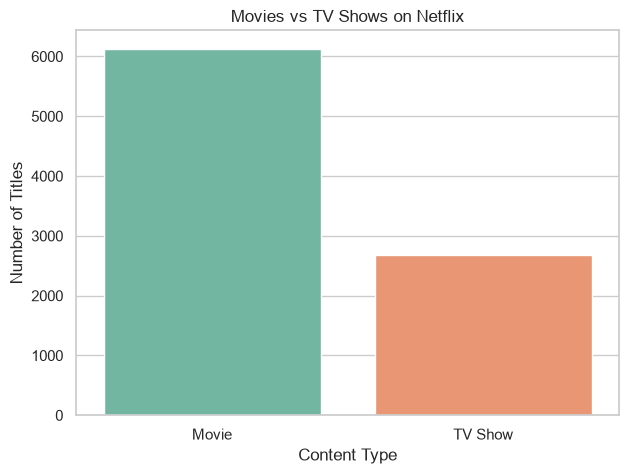

In [15]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='type', hue='type', legend=False, palette='Set2')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

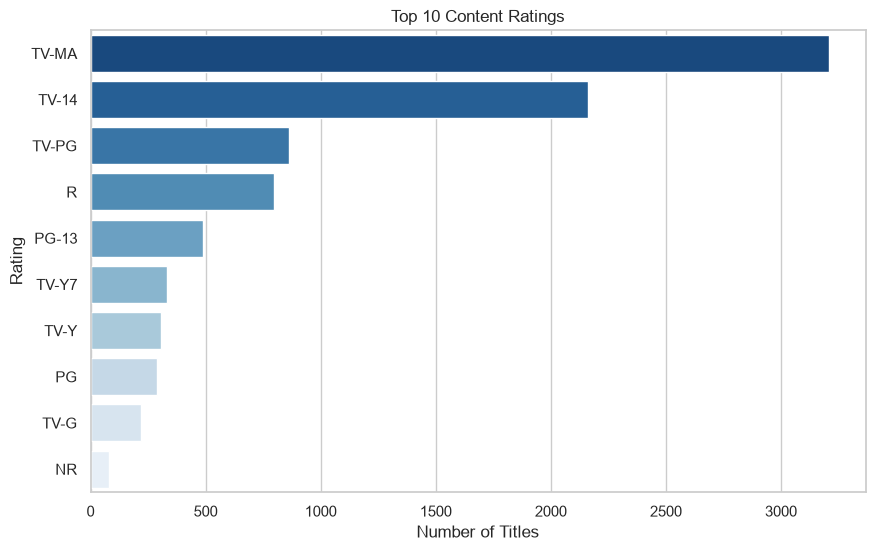

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_ratings.values, y=top_ratings.index, hue=top_ratings.index, legend=False, palette='Blues_r')
plt.title('Top 10 Content Ratings')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.show()

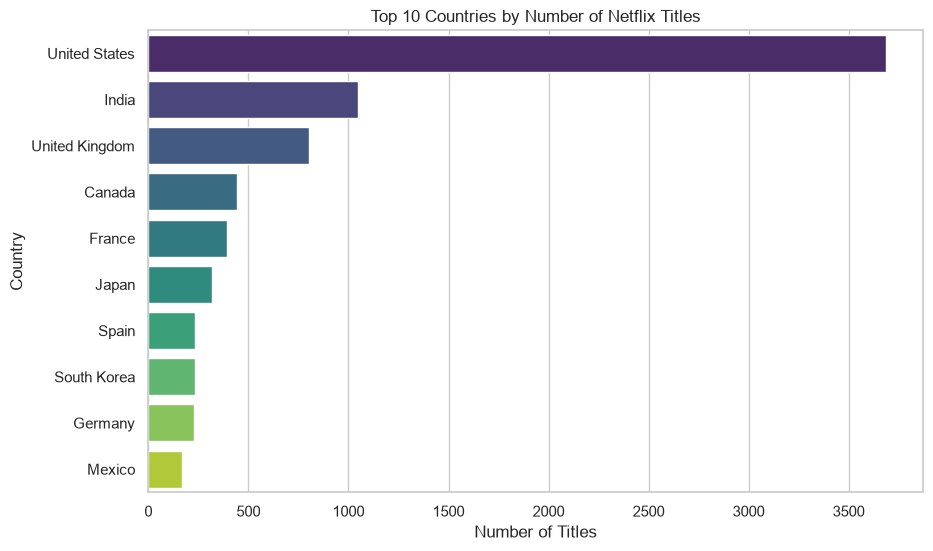

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, legend=False, palette='viridis')
plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

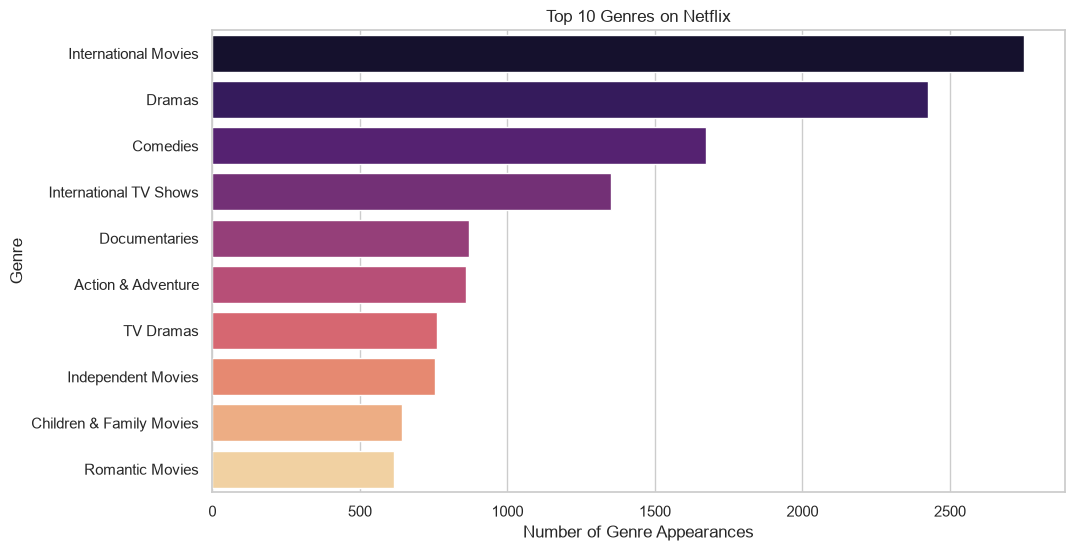

In [18]:
plt.figure(figsize=(11, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, legend=False, palette='magma')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Genre Appearances')
plt.ylabel('Genre')
plt.show()

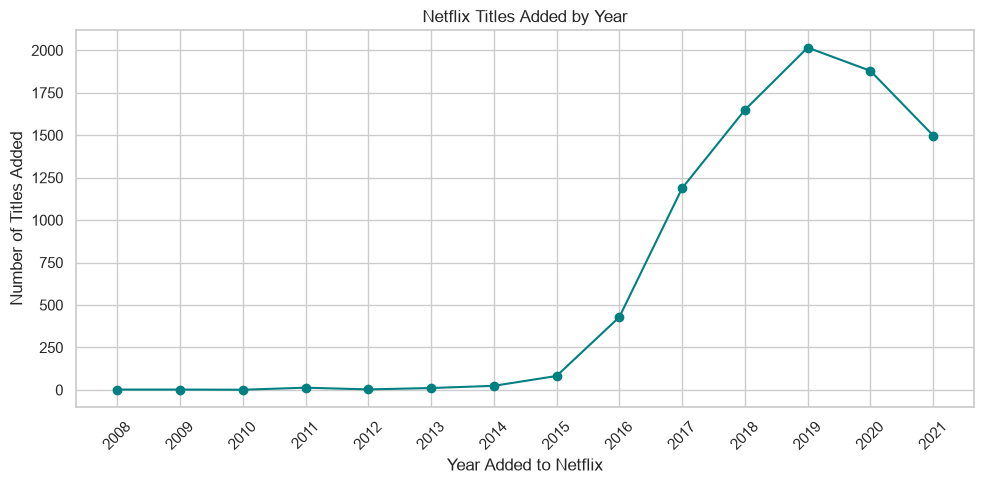

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(titles_added_by_year.index, titles_added_by_year.values, marker='o', color='teal')
plt.title('Netflix Titles Added by Year')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Number of Titles Added')
plt.xticks(titles_added_by_year.index, rotation=45)
plt.tight_layout()
plt.show()

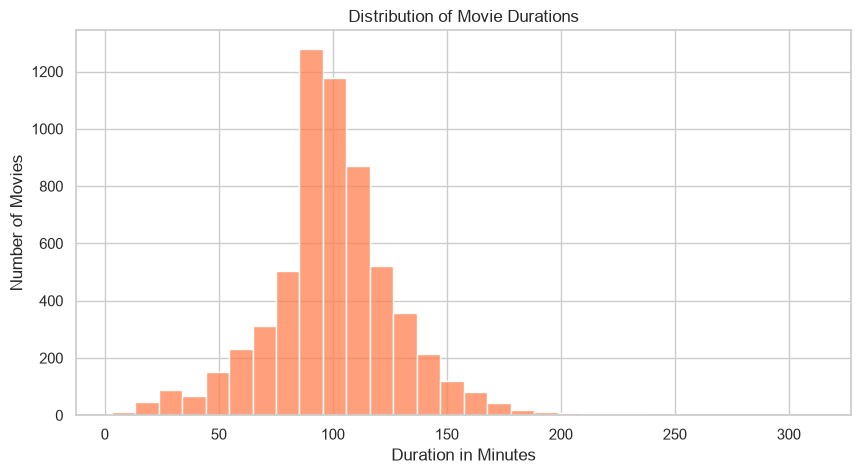

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(movie_durations, bins=30, color='coral')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration in Minutes')
plt.ylabel('Number of Movies')
plt.show()

## 7. Key Findings

- Netflix has **6,131 Movies** and **2,676 TV Shows**. Movies represent **69.6%** of the catalog.
- **TV-MA** is the most common rating, appearing on **3,207 titles**.
- The **United States** is listed for the most titles (**3,689**), followed by **India** (**1,046**).
- **International Movies** is the most common genre category, with **2,752 appearances**.
- The largest number of titles in this dataset were added in **2019** (**2,016 titles**).
- Movies have a median duration of **98 minutes** and an average duration of about **99.6 minutes**.
- TV Shows have a more recent median release year (**2018**) than Movies (**2016**).

## 8. Conclusion

Netflix's catalog in this dataset is mainly made up of movies, with TV-MA as the most common rating. The United States and India appear most often in country information, while International Movies is the leading genre category. The number of recorded additions rose sharply from 2016 and peaked in 2019. This project shows how simple cleaning, counting, grouping, and charts can answer useful questions about a content catalog.